# Monte Carlo Option Pricing

## 1. Research Objective 

We now move on Monte Carlo simulations, which are used to simulate large numbers of possible future asset price outcomes. Monte Carlo estimates option values by averaging discounted payoffs across simulated  price paths, and we hope to see that as the number of simulations increases, the Monte Carlo estimate should converge towarsd the theoretical option value. 

## 2. Geometric Brownian Motion

The most widely used model in quantitative finance to describe the evolution of asset prices is 'Geometric Brownian Motion', which accounts for the randomness of an asset price:

$$ dS_t = \mu S_t dt + \sigma S_t dW_t  $$

where:

- $S_t$ = stock price at time $t$
- $\mu$ = expected continuously compounded rate of return (drift)
- $\sigma$ = volatility

The first time is known as the drift component and the second term is the diffusion component which introduces the randomness into the model through Brownian Motion.

## 3. Risk-Neutral Valuation

When pricing derivatives, we are not interested in predicting the expected return of the underlying asset. Instead, under the assumption of no arbitrage, option prices can be calculated using the risk-neutral measure, where every asset is assumed to grow at the continuously compounded risk-free interest rate.

Under the risk-neutral measure, the drift changes from

$$
\mu \rightarrow r,
$$

giving the stochastic differential equation

$$
dS_t = rS_tdt + \sigma S_t dW_t.
$$

Under this framework, the value of an option is equal to the discounted expected payoff under the risk-neutral measure:

$$
V_0
=
e^{-rT}
\mathbb{E}^{\mathbb{Q}}
\left[g(S_T)\right],
$$

where:

- $V_0$ = option price at time $0$
- $r$ = continuously compounded risk-free interest rate
- $T$ = time to maturity
- $g(S_T)$ = option payoff at maturity
- $\mathbb{E}^{\mathbb{Q}}$ = expectation under the risk-neutral measure

This equation forms the foundation of Monte Carlo option pricing. Rather than attempting to predict the future stock price, we simulate many possible future prices under the risk-neutral measure and estimate the option price by averaging their discounted payoffs.

## 4. Exact Solution of Geometric Brownian Motion

To simulate future stock prices, we require an explicit expression for the stock price at a future time \(T\).

Solving the stochastic differential equation

$$
dS_t = rS_tdt + \sigma S_t dW_t
$$

gives the exact solution

$$
S_T
=
S_0
\exp\left[
\left(r-\frac{1}{2}\sigma^2\right)T
+
\sigma W_T
\right].
$$



This equation enables us to generate random terminal stock prices by sampling independent standard normal random variables. Once a large number of terminal prices have been simulated, the corresponding option payoffs can be calculated and discounted to estimate the option price.

## 5. Monte Carlo Algorithm

### 5.1 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### 5.2 Parameters

In [2]:
S0 = 100     
K = 100      
r = 0.05    
sigma = 0.20 
T = 1    

M = 100000    

### 5.3 Algorithm

In [3]:
Z = np.random.standard_normal(M)

ST = S0 * np.exp(
    (r - 0.5 * sigma**2) * T
    + sigma * np.sqrt(T) * Z
)

In [4]:
call_payoffs = np.maximum(ST - K, 0)
put_payoffs = np.maximum(K - ST, 0)

call_price = np.exp(-r * T) * np.mean(call_payoffs)
put_price = np.exp(-r * T) * np.mean(put_payoffs)

print(f"Monte Carlo European Call Price: {call_price:.4f}")
print(f"Monte Carlo European Put Price:  {put_price:.4f}")

Monte Carlo European Call Price: 10.4945
Monte Carlo European Put Price:  5.5785


### 5.4 Simulating the Paths

In [5]:
steps = 252
dt = T / steps

n_paths = 50

Z = np.random.standard_normal((steps, n_paths))

paths = np.zeros((steps + 1, n_paths))
paths[0] = S0

for t in range(1, steps + 1):
    paths[t] = paths[t - 1] * np.exp(
        (r - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * Z[t - 1]
    )

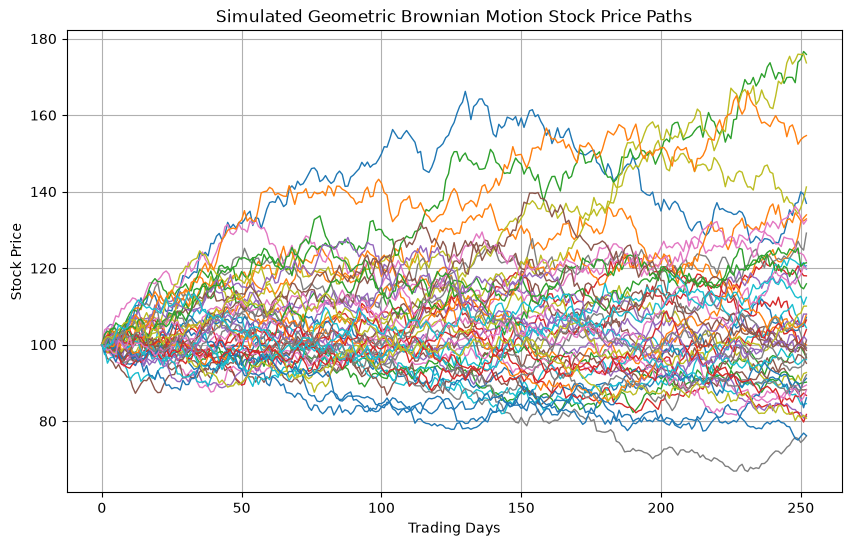

In [6]:
plt.figure(figsize=(10, 6))

for i in range(n_paths):
    plt.plot(paths[:, i], linewidth=1)

plt.title("Simulated Geometric Brownian Motion Stock Price Paths")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price")

plt.grid(True)

plt.show()

## 6. Comparison to Black-Scholes and Binomial Tree

Recall previous results for European Call Price:

- Black-Scholes = 10.4506
- Monte Carlo = 10.4945
- Five-Step Binomial Tree = 10.8059

As we can see the Monte Carlo estimate is very close to Black-Scholes with a percentage error of $\approx 0.42$% which highlights the benefits of using this model. 